In [ ]:
# Retail Analytics Project
'''
This notebook explores a retail transaction dataset to uncover insights into customer behavior,
product performance, and sales trends. '''

## Objectives
#Understand dataset structure
#Clean and validate data
#Perform exploratory data analysis (EDA)
#Generate insights for business decision-making

#Workflow
''' - Inspect data -> Check data quality -> Draw conclusions -> Validate output '''

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#!pip install seaborn
import seaborn as sns

In [3]:
df = pd.read_csv("../data/retail_transaction_dataset.zip")
df.head(10)

,CustomerID,ProductID,Quantity,Price,TransactionDate,PaymentMethod,StoreLocation,ProductCategory,DiscountApplied(%),TotalAmount
0,109318,C,7,80.079844,12/26/2023 12:32,Cash,"176 Andrew Cliffs\nBaileyfort, HI 93354",Books,18.677100,455.862764
1,993229,C,4,75.195229,8/5/2023 0:00,Cash,"11635 William Well Suite 809\nEast Kara, MT 19483",Home Decor,14.121365,258.306546
2,579675,A,8,31.528816,3/11/2024 18:51,Cash,"910 Mendez Ville Suite 909\nPort Lauraland, MO...",Books,15.943701,212.015651
3,799826,D,5,98.880218,10/27/2023 22:00,PayPal,"87522 Sharon Corners Suite 500\nLake Tammy, MO...",Books,6.686337,461.343769
4,121413,A,7,93.188512,12/22/2023 11:38,Cash,"0070 Michelle Island Suite 143\nHoland, VA 80142",Electronics,4.030096,626.030484
5,463050,D,3,54.093152,8/15/2023 4:24,Cash,"8492 Jonathan Drive\nNorth Robertshire, TN 67532",Electronics,10.888768,144.609223
6,888163,D,7,13.121937,12/26/2023 5:32,PayPal,USNV Harrell\nFPO AA 62814,Clothing,16.295127,76.885907
7,843385,A,8,56.025164,10/11/2023 6:48,Debit Card,"489 Juan Loop Apt. 093\nNorth Brettville, WV 7...",Home Decor,6.344306,419.766052
8,839609,B,5,23.857981,2/27/2024 11:13,Credit Card,528 Justin Expressway Apt. 336\nCabreraborough...,Electronics,18.703997,96.977925
9,184135,D,4,63.342777,11/5/2023 1:46,Debit Card,"189 Wright Mews\nMartinfurt, MO 75932",Books,7.640607,234.012018


In [20]:
#data inspection
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   CustomerID          100000 non-null  int64         
 1   ProductID           100000 non-null  object        
 2   Quantity            100000 non-null  int64         
 3   Price               100000 non-null  float64       
 4   TransactionDate     100000 non-null  datetime64[ns]
 5   PaymentMethod       100000 non-null  object        
 6   StoreLocation       100000 non-null  object        
 7   ProductCategory     100000 non-null  object        
 8   DiscountApplied(%)  100000 non-null  float64       
 9   TotalAmount         100000 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(4)
memory usage: 7.6+ MB


In [19]:
df.describe()

,CustomerID,Quantity,Price,TransactionDate,DiscountApplied(%),TotalAmount
count,100000.000000,100000.000000,100000.000000,100000,100000.000000,100000.000000
mean,500463.982180,5.009290,55.067344,2023-10-29 15:40:05.471399936,10.020155,248.334955
min,14.000000,1.000000,10.000430,2023-04-29 22:27:00,0.000046,8.274825
25%,250693.750000,3.000000,32.549474,2023-07-30 06:45:15,5.001013,95.163418
50%,499679.000000,5.000000,55.116789,2023-10-30 05:12:30,10.030353,200.368393
75%,751104.750000,7.000000,77.456763,2024-01-29 05:44:00,15.018367,362.009980
max,999997.000000,9.000000,99.999284,2024-04-28 22:22:00,19.999585,896.141242
std,288460.917524,2.579808,25.971567,NaN,5.779534,184.554792


In [15]:
#check for missing values
df.isnull().sum()

CustomerID            0
ProductID             0
Quantity              0
Price                 0
TransactionDate       0
PaymentMethod         0
StoreLocation         0
ProductCategory       0
DiscountApplied(%)    0
TotalAmount           0
dtype: int64

In [16]:
#detect duplicates
df.duplicated().sum()

np.int64(0)

In [ ]:
#Checking for unique values in CustomerID, ProductID, PaymentMethod, StoreLocation, ProductCategory

In [34]:
unique_customers = df['CustomerID'].unique()
print(len(unique_customers))

95215


In [36]:
unique_products = df['ProductID'].unique()
print(unique_products)
print(len(unique_products))

['C' 'A' 'D' 'B']
4


In [38]:
unique_paymethods = df['PaymentMethod'].unique()
print(unique_paymethods)
print(len(unique_paymethods))

['Cash' 'PayPal' 'Debit Card' 'Credit Card']
4


In [39]:
unique_prodcategories = df['ProductCategory'].unique()
print(unique_prodcategories)
print(len(unique_prodcategories))

['Books' 'Home Decor' 'Electronics' 'Clothing']
4


In [41]:
count_unique_categories = df['ProductCategory'].nunique()
print(count_unique_categories)

4


In [43]:
value_counts = df['ProductID'].value_counts()
print("Value counts:\n", value_counts)

Value counts:
 ProductID
C    25209
D    25042
B    24997
A    24752
Name: count, dtype: int64


In [44]:
value_counts = df['PaymentMethod'].value_counts()
print("Value counts:\n", value_counts)

Value counts:
 PaymentMethod
PayPal         25067
Credit Card    25034
Cash           25008
Debit Card     24891
Name: count, dtype: int64


In [45]:
value_counts = df['ProductCategory'].value_counts()
print("Value counts:\n", value_counts)

Value counts:
 ProductCategory
Clothing       25056
Books          25031
Electronics    24990
Home Decor     24923
Name: count, dtype: int64


In [47]:
#value_counts = df['StoreLocation'].value_counts()
#print("Value counts:\n", value_counts)

Value counts:
 StoreLocation
70264 Jeremy Roads\nWest Melissa, ID 58076              1
PSC 0876, Box 9113\nAPO AE 34943                        1
Unit 8526 Box 8627\nDPO AA 78358                        1
078 Christine Springs\nStewartshire, FL 87447           1
1598 Wells Glen Apt. 101\nJennatown, NM 94851           1
                                                       ..
87522 Sharon Corners Suite 500\nLake Tammy, MO 76234    1
0070 Michelle Island Suite 143\nHoland, VA 80142        1
8492 Jonathan Drive\nNorth Robertshire, TN 67532        1
USNV Harrell\nFPO AA 62814                              1
489 Juan Loop Apt. 093\nNorth Brettville, WV 72610      1
Name: count, Length: 100000, dtype: int64


In [ ]:
#Data Quality Checks
'''
-No missing values detected
-No duplicates records found
-Convert TransactionDate to datetime 
-StoreLocation likely contains street address, town/city, state, postcodes'''


In [ ]:
#Data Cleaning

In [4]:
#Converting TranscationDate from object to datetime
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])

In [51]:
df.duplicated(['StoreLocation']).sum()

np.int64(0)

In [50]:
df.head(30)

,CustomerID,ProductID,Quantity,Price,TransactionDate,PaymentMethod,StoreLocation,ProductCategory,DiscountApplied(%),TotalAmount
0,109318,C,7,80.079844,2023-12-26 12:32:00,Cash,"176 Andrew Cliffs, Baileyfort, HI 93354",Books,18.677100,455.862764
1,993229,C,4,75.195229,2023-08-05 00:00:00,Cash,"11635 William Well Suite 809, East Kara, MT 19483",Home Decor,14.121365,258.306546
2,579675,A,8,31.528816,2024-03-11 18:51:00,Cash,"910 Mendez Ville Suite 909, Port Lauraland, MO...",Books,15.943701,212.015651
3,799826,D,5,98.880218,2023-10-27 22:00:00,PayPal,"87522 Sharon Corners Suite 500, Lake Tammy, MO...",Books,6.686337,461.343769
4,121413,A,7,93.188512,2023-12-22 11:38:00,Cash,"0070 Michelle Island Suite 143, Holand, VA 80142",Electronics,4.030096,626.030484
5,463050,D,3,54.093152,2023-08-15 04:24:00,Cash,"8492 Jonathan Drive, North Robertshire, TN 67532",Electronics,10.888768,144.609223
6,888163,D,7,13.121937,2023-12-26 05:32:00,PayPal,"USNV Harrell, FPO AA 62814",Clothing,16.295127,76.885907
7,843385,A,8,56.025164,2023-10-11 06:48:00,Debit Card,"489 Juan Loop Apt. 093, North Brettville, WV 7...",Home Decor,6.344306,419.766052
8,839609,B,5,23.857981,2024-02-27 11:13:00,Credit Card,"528 Justin Expressway Apt. 336, Cabreraborough...",Electronics,18.703997,96.977925
9,184135,D,4,63.342777,2023-11-05 01:46:00,Debit Card,"189 Wright Mews, Martinfurt, MO 75932",Books,7.640607,234.012018


In [5]:
#Cleaning StoreLocation column
df['StoreLocation'] = df['StoreLocation'].str.replace('\n', ', ')
#Split into its various components
#location_split = df['StoreLocation'].str.split(',', expand=True)
#location_split.columns = ['StreetAddr', 'City', 'StateZIP']
#dropping the previoustly created columns
#df.drop(columns=['StreetAddr', 'City', 'State', 'ZIP'])
#Split StoreLocation into its components
#dropping the previoustly created columns
df['StreetAddr'] = df['StoreLocation'].str.split(',').str[0]
df['City'] = df['StoreLocation'].str.split(',').str[-2].str.strip()
df['State'] = df['StoreLocation'].str.extract(r'\b([A-Z]{2})\s+\d{5}\b')
df['ZIP'] = df['StoreLocation'].str.extract(r'(\d{5})')

In [ ]:
'''
#Split StateZip column
#location_split[['State', 'ZIP']] = location_split['StateZIP'].str.strip().str.split(' ', expand=True)
location_split['State'] = location_split['StateZIP'].str.extract(r'([A-Z]{2})')
location_split['ZIP'] = location_split['StateZIP'].str.extract(r'(\d{5})')
#Clean whitespaces from data in the columns
location_split['City'] = location_split['City'].str.strip()
location_split['State'] = location_split['State'].str.strip()
location_split['ZIP'] = location_split['ZIP'].str.strip()
#attach back to the dataframe
df = pd.concat([df, location_split[['StreetAddr', 'City', 'State', 'ZIP']]], axis='columns') #1=columns, 0=rows '''

In [ ]:
## Location Feature Engineering
'''
-Extracted City, State, and ZIP from StoreLocation
-Enabling geographic analysis of sales performance
-Excluded non-domestic regions (AA, AE, AP) for accurate geographic analysis 
# Special Case: Military Addresses
The dataset included APO/FPO/DPO addresses, which represents U.S. military/diplomatic locations rather than standard geographic regions.
These were categorized separately to avoid distorting regional analysis while still preserving their contribution to overall revenue.'''

In [6]:
df.head(30)

,CustomerID,ProductID,Quantity,Price,TransactionDate,PaymentMethod,StoreLocation,ProductCategory,DiscountApplied(%),TotalAmount,StreetAddr,City,State,ZIP
0,109318,C,7,80.079844,2023-12-26 12:32:00,Cash,"176 Andrew Cliffs, Baileyfort, HI 93354",Books,18.677100,455.862764,176 Andrew Cliffs,Baileyfort,HI,93354
1,993229,C,4,75.195229,2023-08-05 00:00:00,Cash,"11635 William Well Suite 809, East Kara, MT 19483",Home Decor,14.121365,258.306546,11635 William Well Suite 809,East Kara,MT,11635
2,579675,A,8,31.528816,2024-03-11 18:51:00,Cash,"910 Mendez Ville Suite 909, Port Lauraland, MO...",Books,15.943701,212.015651,910 Mendez Ville Suite 909,Port Lauraland,MO,99563
3,799826,D,5,98.880218,2023-10-27 22:00:00,PayPal,"87522 Sharon Corners Suite 500, Lake Tammy, MO...",Books,6.686337,461.343769,87522 Sharon Corners Suite 500,Lake Tammy,MO,87522
4,121413,A,7,93.188512,2023-12-22 11:38:00,Cash,"0070 Michelle Island Suite 143, Holand, VA 80142",Electronics,4.030096,626.030484,0070 Michelle Island Suite 143,Holand,VA,80142
5,463050,D,3,54.093152,2023-08-15 04:24:00,Cash,"8492 Jonathan Drive, North Robertshire, TN 67532",Electronics,10.888768,144.609223,8492 Jonathan Drive,North Robertshire,TN,67532
6,888163,D,7,13.121937,2023-12-26 05:32:00,PayPal,"USNV Harrell, FPO AA 62814",Clothing,16.295127,76.885907,USNV Harrell,USNV Harrell,AA,62814
7,843385,A,8,56.025164,2023-10-11 06:48:00,Debit Card,"489 Juan Loop Apt. 093, North Brettville, WV 7...",Home Decor,6.344306,419.766052,489 Juan Loop Apt. 093,North Brettville,WV,72610
8,839609,B,5,23.857981,2024-02-27 11:13:00,Credit Card,"528 Justin Expressway Apt. 336, Cabreraborough...",Electronics,18.703997,96.977925,528 Justin Expressway Apt. 336,Cabreraborough,SD,17915
9,184135,D,4,63.342777,2023-11-05 01:46:00,Debit Card,"189 Wright Mews, Martinfurt, MO 75932",Books,7.640607,234.012018,189 Wright Mews,Martinfurt,MO,75932


In [7]:
df['StreetAddr'].nunique()

97643

In [67]:
value_counts = df['State'].value_counts()
print("Value counts:\n", value_counts)

Value counts:
 State
AE    3681
AA    3594
AP    3531
ME    1584
OR    1582
      ... 
WA    1463
AS    1453
CA    1452
IA    1436
MI    1428
Name: count, Length: 62, dtype: int64


In [8]:
df[['StreetAddr', 'City', 'State', 'ZIP']].isnull().sum()

StreetAddr    0
City          0
State         0
ZIP           0
dtype: int64

In [9]:
df.dtypes

CustomerID                     int64
ProductID                     object
Quantity                       int64
Price                        float64
TransactionDate       datetime64[ns]
PaymentMethod                 object
StoreLocation                 object
ProductCategory               object
DiscountApplied(%)           float64
TotalAmount                  float64
StreetAddr                    object
City                          object
State                         object
ZIP                           object
dtype: object

In [10]:
df['ZIP'] = df['ZIP'].astype(str)

In [11]:
#df.drop(columns='RegionType')
df['RegionType'] = np.where(df['State'].isin(['AA', 'AE', 'AP']), 'Military/Abroad', 'Domestic')

In [12]:
value_counts = df['RegionType'].value_counts()
print("Value counts:\n", value_counts)

Value counts:
 RegionType
Domestic           89194
Military/Abroad    10806
Name: count, dtype: int64


In [13]:
#Splitting TransactionDate for further time series analysis
df['Date'] = df['TransactionDate'].dt.date
df['Month'] = df['TransactionDate'].dt.month_name()
df['DayOfWeek'] = df['TransactionDate'].dt.day_name()
df['Hour'] = df['TransactionDate'].dt.hour
df['Quarter'] = df['TransactionDate'].dt.to_period('Q')
df['Year'] = df['TransactionDate'].dt.year

In [14]:
df.drop(columns='StreetAddr')

,CustomerID,ProductID,Quantity,Price,TransactionDate,PaymentMethod,StoreLocation,ProductCategory,DiscountApplied(%),TotalAmount,City,State,ZIP,RegionType,Date,Month,DayOfWeek,Hour,Quarter,Year
0,109318,C,7,80.079844,2023-12-26 12:32:00,Cash,"176 Andrew Cliffs, Baileyfort, HI 93354",Books,18.677100,455.862764,Baileyfort,HI,93354,Domestic,2023-12-26,December,Tuesday,12,2023Q4,2023
1,993229,C,4,75.195229,2023-08-05 00:00:00,Cash,"11635 William Well Suite 809, East Kara, MT 19483",Home Decor,14.121365,258.306546,East Kara,MT,11635,Domestic,2023-08-05,August,Saturday,0,2023Q3,2023
2,579675,A,8,31.528816,2024-03-11 18:51:00,Cash,"910 Mendez Ville Suite 909, Port Lauraland, MO...",Books,15.943701,212.015651,Port Lauraland,MO,99563,Domestic,2024-03-11,March,Monday,18,2024Q1,2024
3,799826,D,5,98.880218,2023-10-27 22:00:00,PayPal,"87522 Sharon Corners Suite 500, Lake Tammy, MO...",Books,6.686337,461.343769,Lake Tammy,MO,87522,Domestic,2023-10-27,October,Friday,22,2023Q4,2023
4,121413,A,7,93.188512,2023-12-22 11:38:00,Cash,"0070 Michelle Island Suite 143, Holand, VA 80142",Electronics,4.030096,626.030484,Holand,VA,80142,Domestic,2023-12-22,December,Friday,11,2023Q4,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,726461,A,2,56.078258,2023-07-17 16:59:00,Credit Card,"3632 Darren Station Apt. 553, Ericaborough, RI...",Clothing,18.345145,91.581240,Ericaborough,RI,37695,Domestic,2023-07-17,July,Monday,16,2023Q3,2023
99996,328056,A,6,88.516406,2023-05-30 09:04:00,Credit Card,"821 Taylor Shoals, Evansville, IL 70845",Electronics,3.995541,509.878179,Evansville,IL,70845,Domestic,2023-05-30,May,Tuesday,9,2023Q2,2023
99997,887304,B,4,72.385564,2023-08-25 07:59:00,Credit Card,"50653 Kara Lakes, Stephanieborough, RI 94492",Clothing,17.423979,239.092472,Stephanieborough,RI,50653,Domestic,2023-08-25,August,Friday,7,2023Q3,2023
99998,326401,C,5,66.542239,2024-02-05 19:45:00,PayPal,"18756 Mcfarland Way Suite 866, Barnettside, PR...",Electronics,14.345018,284.983717,Barnettside,PR,18756,Domestic,2024-02-05,February,Monday,19,2024Q1,2024


In [15]:
df.head(10)

,CustomerID,ProductID,Quantity,Price,TransactionDate,PaymentMethod,StoreLocation,ProductCategory,DiscountApplied(%),TotalAmount,...,City,State,ZIP,RegionType,Date,Month,DayOfWeek,Hour,Quarter,Year
0,109318,C,7,80.079844,2023-12-26 12:32:00,Cash,"176 Andrew Cliffs, Baileyfort, HI 93354",Books,18.677100,455.862764,...,Baileyfort,HI,93354,Domestic,2023-12-26,December,Tuesday,12,2023Q4,2023
1,993229,C,4,75.195229,2023-08-05 00:00:00,Cash,"11635 William Well Suite 809, East Kara, MT 19483",Home Decor,14.121365,258.306546,...,East Kara,MT,11635,Domestic,2023-08-05,August,Saturday,0,2023Q3,2023
2,579675,A,8,31.528816,2024-03-11 18:51:00,Cash,"910 Mendez Ville Suite 909, Port Lauraland, MO...",Books,15.943701,212.015651,...,Port Lauraland,MO,99563,Domestic,2024-03-11,March,Monday,18,2024Q1,2024
3,799826,D,5,98.880218,2023-10-27 22:00:00,PayPal,"87522 Sharon Corners Suite 500, Lake Tammy, MO...",Books,6.686337,461.343769,...,Lake Tammy,MO,87522,Domestic,2023-10-27,October,Friday,22,2023Q4,2023
4,121413,A,7,93.188512,2023-12-22 11:38:00,Cash,"0070 Michelle Island Suite 143, Holand, VA 80142",Electronics,4.030096,626.030484,...,Holand,VA,80142,Domestic,2023-12-22,December,Friday,11,2023Q4,2023
5,463050,D,3,54.093152,2023-08-15 04:24:00,Cash,"8492 Jonathan Drive, North Robertshire, TN 67532",Electronics,10.888768,144.609223,...,North Robertshire,TN,67532,Domestic,2023-08-15,August,Tuesday,4,2023Q3,2023
6,888163,D,7,13.121937,2023-12-26 05:32:00,PayPal,"USNV Harrell, FPO AA 62814",Clothing,16.295127,76.885907,...,USNV Harrell,AA,62814,Military/Abroad,2023-12-26,December,Tuesday,5,2023Q4,2023
7,843385,A,8,56.025164,2023-10-11 06:48:00,Debit Card,"489 Juan Loop Apt. 093, North Brettville, WV 7...",Home Decor,6.344306,419.766052,...,North Brettville,WV,72610,Domestic,2023-10-11,October,Wednesday,6,2023Q4,2023
8,839609,B,5,23.857981,2024-02-27 11:13:00,Credit Card,"528 Justin Expressway Apt. 336, Cabreraborough...",Electronics,18.703997,96.977925,...,Cabreraborough,SD,17915,Domestic,2024-02-27,February,Tuesday,11,2024Q1,2024
9,184135,D,4,63.342777,2023-11-05 01:46:00,Debit Card,"189 Wright Mews, Martinfurt, MO 75932",Books,7.640607,234.012018,...,Martinfurt,MO,75932,Domestic,2023-11-05,November,Sunday,1,2023Q4,2023


In [ ]:
#Export the cleaned data

In [16]:
df_domestic = df[df['RegionType'] == 'Domestic']
df_abroad = df[df['RegionType'] == 'Military/Abroad']
df_domestic.to_csv('../outputs/domestic_transactions.csv', index=False)
df_abroad.to_csv('../outputs/abroad_transactions.csv', index=False)

In [ ]:
#Exploratory Data Analysis

In [20]:
#Revenue
total_revenue = df['TotalAmount'].sum()
total_revenue.round(2)

np.float64(24833495.51)

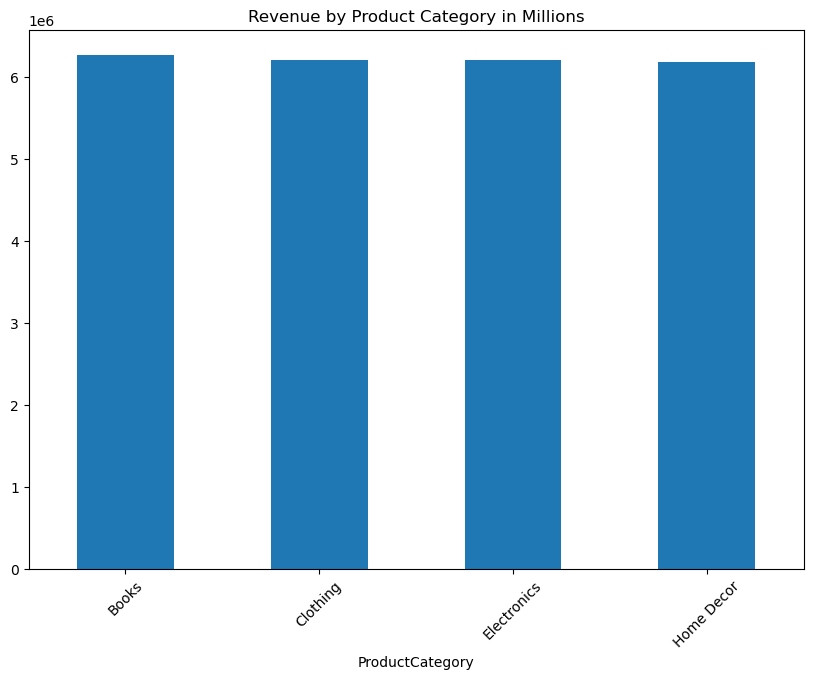

In [22]:
#Sales by Product Category
category_sales = df.groupby('ProductCategory')['TotalAmount'].sum().sort_values(ascending=False)

category_sales.plot(kind='bar', figsize=(10,7))
plt.title("Revenue by Product Category in Millions")
plt.xticks(rotation=45)
plt.savefig("../outputs/category_sales.png")
plt.show()

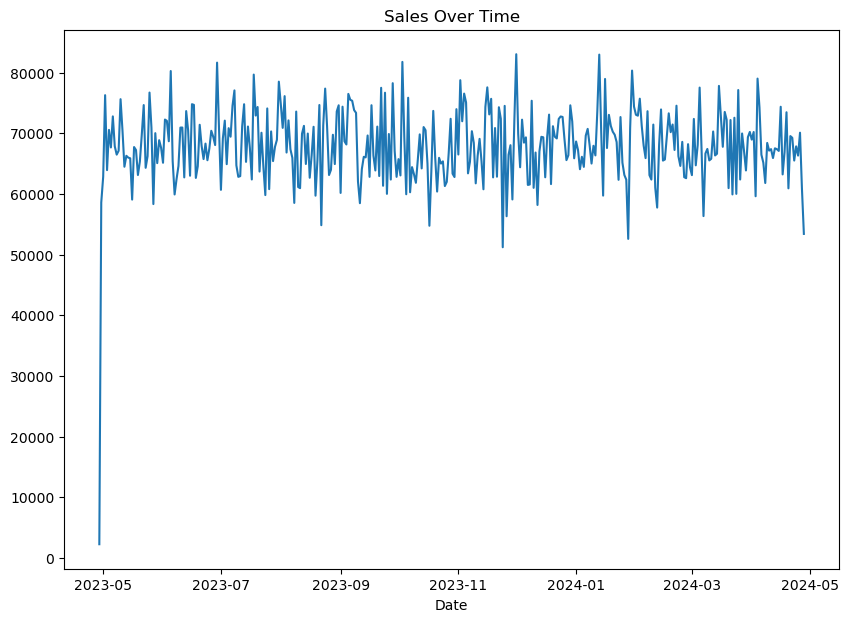

In [24]:
#Sales Over Time
daily_sales = df.groupby('Date')['TotalAmount'].sum()

plt.figure(figsize=(10,7))
daily_sales.plot()
plt.title("Sales Over Time")
plt.savefig("../outputs/sales_over_time.png")
plt.show()

In [25]:
#Total Revenue/Sales by Payment Method
df.groupby('PaymentMethod')['TotalAmount'].sum()

PaymentMethod
Cash           6.207206e+06
Credit Card    6.203538e+06
Debit Card     6.202999e+06
PayPal         6.219753e+06
Name: TotalAmount, dtype: float64

In [27]:
df_domestic.groupby('PaymentMethod')['TotalAmount'].sum().round(2)

PaymentMethod
Cash           5517659.90
Credit Card    5525045.61
Debit Card     5531265.13
PayPal         5565806.37
Name: TotalAmount, dtype: float64

In [31]:
df_domestic.groupby('ProductCategory')['PaymentMethod'].value_counts()


ProductCategory  PaymentMethod
Books            PayPal           5676
                 Credit Card      5584
                 Debit Card       5524
                 Cash             5511
Clothing         Credit Card      5636
                 PayPal           5631
                 Cash             5577
                 Debit Card       5505
Electronics      Cash             5609
                 Credit Card      5586
                 Debit Card       5564
                 PayPal           5515
Home Decor       Debit Card       5649
                 PayPal           5582
                 Cash             5525
                 Credit Card      5520
Name: count, dtype: int64

In [34]:
df_domestic.groupby('City')['TotalAmount'].sum().round(2).sort_values(ascending=False)

City
West Michael            21537.96
North Michael           20516.45
Lake Michael            19967.32
Port Michael            19728.47
New Michael             19358.90
                          ...   
Gabrielletown               8.63
West Sarahfort              8.58
Osbornetown                 8.57
Atkinsonton                 8.46
North Crystalborough        8.27
Name: TotalAmount, Length: 35680, dtype: float64

In [36]:
df_domestic.groupby('State')['TotalAmount'].sum().round(2).sort_values(ascending=False)

State
MH    403258.89
ME    400060.79
AR    393846.36
TX    392307.76
OR    392179.25
IL    390382.02
SD    389232.15
IN    387954.65
SC    387669.86
MT    387203.24
NY    386223.36
AZ    385888.21
PW    383851.75
FM    383675.96
TN    383099.73
NH    382609.56
MO    382235.03
MA    382227.27
MN    379994.20
WV    379524.46
WY    379330.35
GA    378784.54
PR    378300.27
RI    377899.99
AL    377146.31
NM    375876.47
VI    375715.40
MD    375634.58
ID    375415.46
CT    375277.11
OH    375205.28
DE    374748.28
MS    374423.80
PA    374031.54
ND    373729.68
NE    373432.42
MP    373411.37
DC    371508.68
WA    370756.24
NJ    370251.87
AK    370044.47
LA    369637.91
CA    369038.36
HI    368751.39
GU    367411.65
CO    366379.20
VT    365855.94
OK    365382.03
KY    364787.84
KS    364009.42
WI    363597.03
IA    361787.98
UT    361118.29
VA    359511.77
NV    357844.53
MI    356364.59
AS    352518.34
NC    351596.80
FL    349835.33
Name: TotalAmount, dtype: float64

In [38]:
df_domestic.groupby('ProductCategory')['Quantity'].sum().sort_values(ascending=False)

ProductCategory
Books          112396
Electronics    111723
Clothing       111392
Home Decor     111241
Name: Quantity, dtype: int64

In [39]:
df_domestic.groupby('ProductCategory')['TotalAmount'].mean().round(2).sort_values(ascending=False)

ProductCategory
Books          250.00
Electronics    248.08
Home Decor     247.71
Clothing       247.09
Name: TotalAmount, dtype: float64

In [41]:
df_domestic.groupby('ProductCategory')['DiscountApplied(%)'].mean()

ProductCategory
Books          10.025473
Clothing       10.031997
Electronics     9.975986
Home Decor     10.072154
Name: DiscountApplied(%), dtype: float64

In [42]:
df_domestic.groupby('Date')['TotalAmount'].sum().sort_values(ascending=False)

Date
2023-10-03    76518.394632
2023-06-05    74954.910406
2024-01-13    74095.757432
2023-12-01    73459.350393
2024-01-30    73410.645464
                  ...     
2024-03-07    48438.293173
2024-04-28    47538.430284
2024-01-28    46028.786211
2023-11-24    45966.309410
2023-04-29     2065.766399
Name: TotalAmount, Length: 366, dtype: float64

In [44]:
#Best performingg Quarters by sales
df_domestic.groupby('Quarter')['TotalAmount'].sum().round(2).sort_values(ascending=False)

Quarter
2023Q3    5601989.64
2023Q4    5569468.41
2024Q1    5544399.36
2023Q2    3754785.16
2024Q2    1669134.43
Freq: Q-DEC, Name: TotalAmount, dtype: float64

In [48]:
#Best performing regions by Quarter
quarterly_state = df_domestic.groupby(['Quarter', 'State'])['TotalAmount'].sum().reset_index()
top_regions = quarterly_state.sort_values(['Quarter', 'TotalAmount'], ascending=[True, False])
top_regions

,Quarter,State,TotalAmount
24,2023Q2,ME,73844.967282
55,2023Q2,WA,71730.130864
19,2023Q2,KS,71565.091405
26,2023Q2,MI,71113.736559
17,2023Q2,IL,70758.359344
...,...,...,...
272,2024Q2,NJ,23383.095447
284,2024Q2,SD,23226.702851
292,2024Q2,WI,22961.241006
287,2024Q2,UT,22779.891549


In [49]:
top_per_quarter = (
    quarterly_state
    .sort_values(['Quarter', 'TotalAmount'], ascending=[True, False])
    .groupby('Quarter')
    .head(20)
)

In [50]:
top_per_quarter

,Quarter,State,TotalAmount
24,2023Q2,ME,73844.967282
55,2023Q2,WA,71730.130864
19,2023Q2,KS,71565.091405
26,2023Q2,MI,71113.736559
17,2023Q2,IL,70758.359344
...,...,...,...
253,2024Q2,IL,29836.439910
270,2024Q2,NE,29804.547008
257,2024Q2,LA,29709.846837
244,2024Q2,DC,29688.985023


In [52]:
df_domestic.groupby('DayOfWeek')['TotalAmount'].sum().round(2).sort_values(ascending=False)

DayOfWeek
Thursday     3212720.83
Saturday     3192900.49
Wednesday    3160975.91
Tuesday      3150448.92
Friday       3150414.75
Sunday       3149909.96
Monday       3122406.15
Name: TotalAmount, dtype: float64

In [53]:
df_domestic.groupby('Month')['TotalAmount'].sum().round(2).sort_values(ascending=False)

Month
January      1907450.14
July         1899332.40
December     1899117.74
March        1876504.00
August       1875500.30
May          1859029.12
November     1846404.29
June         1839983.23
September    1827156.93
October      1823946.37
February     1760445.22
April        1724907.25
Name: TotalAmount, dtype: float64

In [54]:
df.groupby('State')['TotalAmount'].mean().sort_values(ascending=False)

State
TX    258.267126
IL    255.485614
MH    255.388787
AR    254.751848
SD    254.400099
         ...    
NV    241.623584
GU    241.083761
AL    239.154287
FL    239.121894
NC    236.447075
Name: TotalAmount, Length: 62, dtype: float64

In [55]:
df.groupby('State')['PaymentMethod'].value_counts(normalize=True)

State  PaymentMethod
AA     Cash             0.257652
       Debit Card       0.251252
       Credit Card      0.249583
       PayPal           0.241514
AE     Credit Card      0.256452
                          ...   
WV     Debit Card       0.238251
WY     Credit Card      0.267727
       Debit Card       0.250497
       PayPal           0.243870
       Cash             0.237906
Name: proportion, Length: 248, dtype: float64

In [4]:
df_domestic = pd.read_csv("../outputs/domestic_transactions.csv")

In [5]:
df_domestic.groupby('State')['DiscountApplied(%)'].mean()

State
AK    10.334856
AL    10.157874
AR     9.871423
AS     9.792979
AZ    10.002509
CA     9.870338
CO    10.108868
CT     9.872634
DC    10.140552
DE    10.254522
FL    10.155623
FM    10.350001
GA    10.263907
GU    10.058081
HI    10.075424
IA    10.071427
ID     9.869337
IL    10.037828
IN     9.964837
KS    10.315240
KY     9.939740
LA    10.054428
MA     9.889730
MD    10.307651
ME     9.963801
MH     9.875959
MI    10.121289
MN    10.104922
MO    10.131139
MP    10.048076
MS    10.088177
MT     9.947118
NC     9.937130
ND    10.046342
NE    10.064105
NH     9.995741
NJ    10.196357
NM     9.950635
NV    10.036294
NY    10.180776
OH    10.039534
OK    10.109372
OR     9.999497
PA     9.981513
PR    10.070933
PW    10.046914
RI     9.687504
SC     9.810904
SD     9.880617
TN     9.737924
TX     9.579521
UT     9.762088
VA    10.093846
VI     9.805046
VT     9.922453
WA    10.354054
WI    10.214226
WV    10.163295
WY     9.889190
Name: DiscountApplied(%), dtype: float64